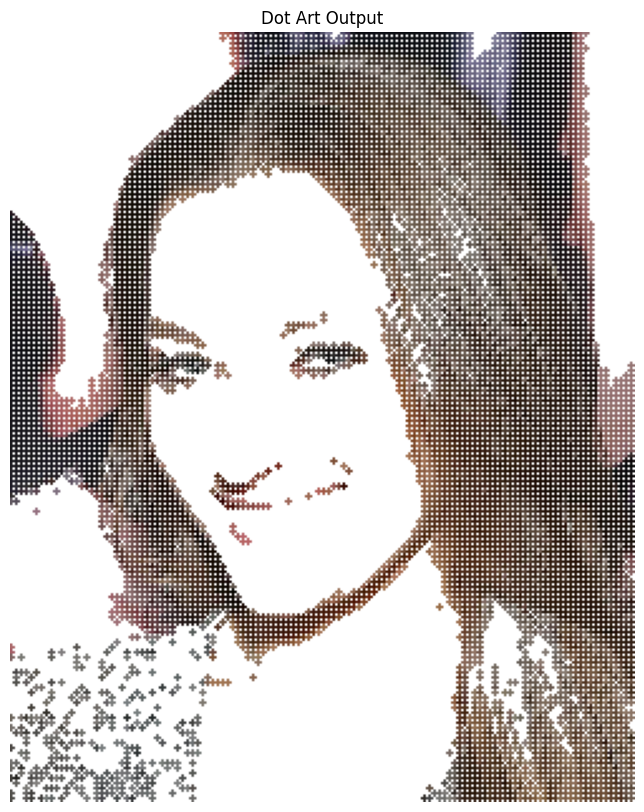

Dot-art image saved as dot_art_output.png


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# LOAD IMAGE
image_path = "/content/las-vegas-nv-adult-film-actress-dani-daniels-attends-the-2014-avn-adult-entertainment-expo-at.webp"
img = cv2.imread(image_path)

if img is None:
    raise ValueError("Image not found. Check the file path.")

# Convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
scale_percent = 50
width = int(img.shape[1] * scale_percent / 100)
height = int(img.shape[0] * scale_percent / 100)
img = cv2.resize(img, (width, height))
# gray scale conversion
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
# creating black canvas
canvas = np.ones((height, width, 3), dtype=np.uint8) * 255
# dot settings
spacing = 2
max_radius = 2
# drawing dots
for y in range(0, height, spacing):
    for x in range(0, width, spacing):

        intensity = gray[y, x]

        # Darker pixel -> bigger dot
        radius = int((255 - intensity) / 255 * max_radius)

        if radius > 0:
            color = tuple(map(int, img[y, x])) # Convert np.uint8 to int for cv2.circle
            cv2.circle(canvas, (x, y), radius, color, -1)
# results
plt.figure(figsize=(10, 10))
plt.imshow(canvas)
plt.axis('off')
plt.title("Dot Art Output")
plt.show()
#save
output = cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR)
cv2.imwrite("dot_art_output.png", output)

print("Dot-art image saved as dot_art_output.png")

Enter function: x**2 + y**9
What do you want to plot? (Example: f vs x): y


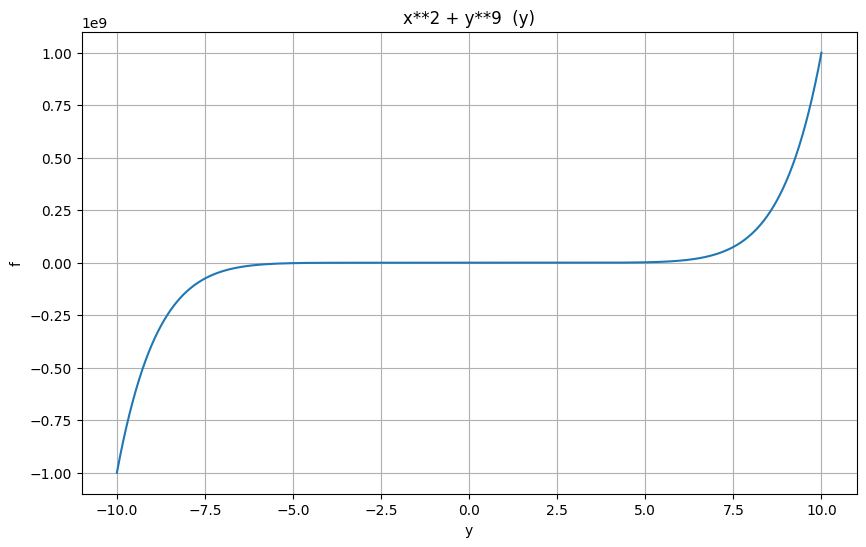

In [17]:
import numpy as np
import matplotlib.pyplot as plt
# STEP 1 : ENTER FUNCTION
function_input = input("Enter function: ")
# STEP 2 : ASK WHAT TO PLOT
plot_type = input(
    "What do you want to plot? (Example: f vs x): "
)
# STEP 3 : EXTRACT VARIABLE
# Example:
# f vs x  -> variable = x
# f vs t  -> variable = t

variable = plot_type.split("vs")[-1].strip()
# STEP 4 : CREATE VARIABLE RANGE
values = np.linspace(-10, 10, 2000)
# Create variable dynamically
globals()[variable] = values
# STEP 5 : EVALUATE FUNCTION
y = eval(function_input)
# STEP 6 : PLOT GRAPh
plt.figure(figsize=(10, 6))

plt.plot(values, y)

plt.xlabel(variable)
plt.ylabel("f")

plt.title(f"{function_input}  ({plot_type})")

plt.grid(True)

plt.show()

Enter 3D function f(x,y): x**2 + x*y + 2
What do you want to plot? (Example: f vs x,y): x,y


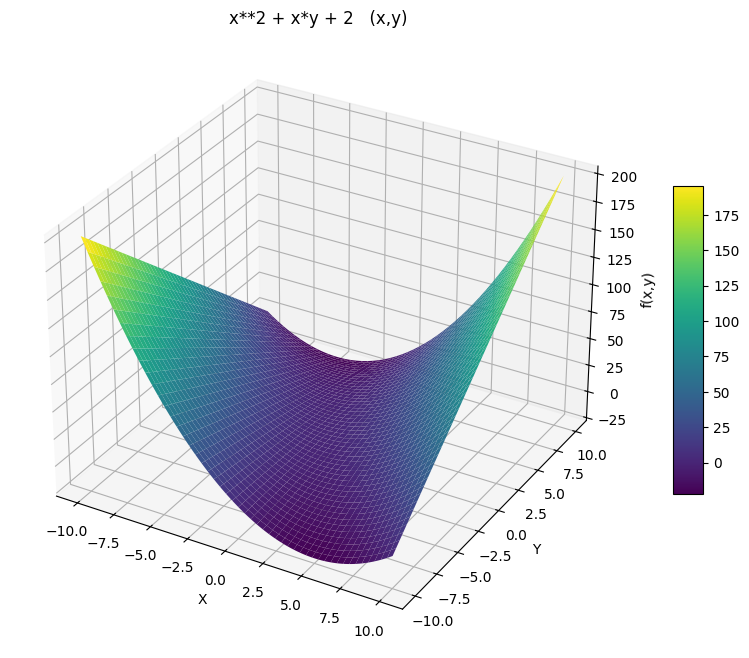

In [22]:
import numpy as np
import matplotlib.pyplot as plt
# Example:
# x**2 + y**2
# np.sin(x)*np.cos(y)
# np.exp(-(x**2 + y**2))

function_input = input("Enter 3D function f(x,y): ")
plot_type = input(
    "What do you want to plot? (Example: f vs x,y): "
)
x = np.linspace(-10, 10, 300)
y = np.linspace(-10, 10, 300)

X, Y = np.meshgrid(x, y)
Z = eval(
    function_input,
    {
        "np": np,
        "x": X,
        "y": Y
    }
)
fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap='viridis',
    edgecolor='none'
)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x,y)')

ax.set_title(
    f"{function_input}   ({plot_type})"
)
fig.colorbar(
    surface,
    shrink=0.5,
    aspect=10
)
plt.show()